# Goal

While I think that the problem is probably not stiff, there is definitely a need for a differentiable
adaptive step solver to circumvent spurious damping due to discretization error.

## Conclusions:

- In the Wigner function, I see actual frequencies, whereas in the differential equation, I see angular frequencies!
    If I solve the SDE with $\omega=4000$, I will see that (if r_fac is high enough), the solution will be close to the
    analytical solution of cos(omega (t-t0)), whereas in the Wigner function, I will see a horizontal spike at
    omega/(2pi) according to the equation omega = 2pi f of course.
- The adaptive explicit diffrax solver tsit5 unfortunately takes a long time for quite suboptimal results. Definitely
    better than RK4 with low r_fac, but still not perfect
- Therefore, the solution rather lies in choosing a sufficient high r_fac and using RK4. However, r_fac of course,
    should couple to omega itself. Therefore, I should set an upper limit on what kind of signals I want to model
    and then choose r_fac good enough so as to faithfully reconstruct those signals. For example, the maximum
    difference between the numerical and analytical solution in case of a simple harmonic oscillator of angular
    frequency omega=4000 is 0.01 in case r_fac is set to 100. This could be the rough guideline.

In [7]:
%matplotlib inline
from phase_III.strain import *

# Updated version of `phase_III/signal_reconstruction.py`
from phase_II.nifty_re_playground.strain_tools import *
from phase_III.strain import *
import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)
import nifty.re as jft
from phase_III.useful.helpers import get_oscillator_sample
import matplotlib.pyplot as plt
import numpy as np
key = jax.random.key(34)

In [19]:
omega0 = 4000

GW150914 = StrainSignalInference(
    key=key,
    event_name="GW150914",
    detector="H1",
    data_duration_of_hdf5_file="4096sec",
    stationarity_time_scale=32,
    e_fac=1,
    r_fac=100,
    alpha_taper_on_data=.1,
    out_name='osc_dlt_later'
)

signal_domain = GW150914.machinery.t_ss
dt = signal_domain[1]-signal_domain[0]
print("dt and inverse: ", dt, dt**-1, " and N: ", len(signal_domain))
target_domain = GW150914.machinery.t_ds

oscillator_prior_dct = {
    "frequency": {"offset_mean": omega0, "offset_std": (1e-5, 1e-16), "fluctuations": (1e-16, 1e-16), "loglogavgslope": (-4, 1e-16)},  # log fluctuations...
    "damping": {"offset_mean": 0, "offset_std": (1e-5, 1e-16), "fluctuations": (1e-16, 1e-16), "loglogavgslope": (-4, 1e-16)},
    "force": {"offset_mean": 0, "offset_std": (1e-5, 1e-16), "fluctuations": (1e-16, 1e-16), "loglogavgslope": (0, 0.001), },
    "global_amplitude": (1, 1e-16),
    "init_condition": (1, 0),
}

signal_prior = StochasticOscillatorPrior(oscillator_prior_dct, signal_time_domain=signal_domain, localize_force=None, couple_force_to_frequency=False)
oscillator = HarmonicOscillator(signal_domain_times=signal_domain, signal_prior=signal_prior, solver='rk4', dfe='rhs_simple_ho', normalize=False)

Assumed noise stationarity timescale for Welch-average:  32  seconds.
	Constructing 15 windows over which we average.
	Mean variance of tapered windows: 4.54237106804325
	Compare with area under welch ps:  4.5444512277217575
Hermitian symmetry OK. Max difference between pos and neg is  4.440892098500626e-16

Waveform query for GW150914. Found 1 local matche(s):
	0: 	IGWN-GWTC2p1-v2-GW150914_095045_PEDataRelease_mixed_cosmo.h5
Using  IGWN-GWTC2p1-v2-GW150914_095045_PEDataRelease_mixed_cosmo.h5


2026-04-07  13:52:47 PESummary WARNING : Could not find f_start in input file and one was not passed from the command line. Using 20.0Hz as default


Waveform model bank names:  C01:IMRPhenomXPHM C01:Mixed C01:SEOBNRv4PHM
Using  IMRPhenomXPHM  model.
Input gps center:  1126259462.4  maximum likelihood merger time from template:  1126259462.4241831
dt and inverse:  2.4414062500532907e-06 409599.9999910593  and N:  819200

You are trying to set up the frequency prior for the oscillator with mean 4000.0±(1e-05, 1e-16). To ensure positivity, 
we are exponentiating internally and therefore changing the mean and standard deviation values to 
 16.59±((Array(0., dtype=float64), Array(0., dtype=float64))).
If you are unsure this has the desired effect, check samples via `StochasticOscillatorPrior.plot_omega_samples`.


The following shows the solution to a simple harmonic oscillator (no force, no damping, constant natural frequency).
The sampling frequency is  409599.9999910593  while the natural frequency is  636.6197723675814


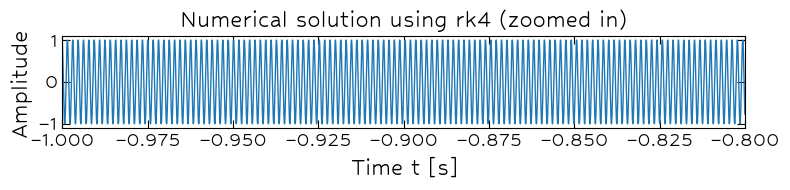

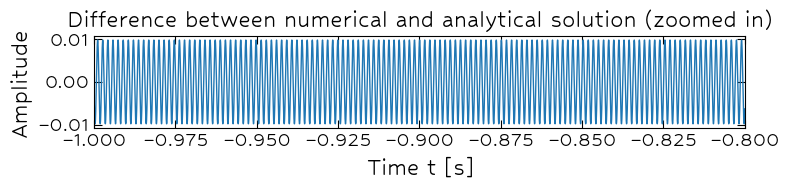

In [20]:
key, waveform_sample, omega_sample, gamma_sample, force_sample = get_oscillator_sample(oscillator, key)
times = oscillator.evolution_times
dt = times[1]-times[0]

print("The following shows the solution to a simple harmonic oscillator (no force, no damping, constant natural frequency).")
print("The sampling frequency is ", 1/dt, " while the natural frequency is ", omega0/(2*np.pi))

_ = plt.figure(figsize=(8, 2))
plt.plot(times, waveform_sample)
thesis_plot(yl="Amplitude", title="Numerical solution using rk4 (zoomed in)", xlim=(-1, -0.8))

_ = plt.figure(figsize=(8, 2))
plt.plot(times, waveform_sample - np.cos(4000 * (times-times[0])))
thesis_plot(yl="Amplitude", title="Difference between numerical and analytical solution (zoomed in)",  xlim=(-1, -0.8))

How does the maximum error change when varying the natural angular frequency at a fixed r_fac?

In [22]:
GW150914 = StrainSignalInference(
    key=key,
    event_name="GW150914",
    detector="H1",
    data_duration_of_hdf5_file="4096sec",
    stationarity_time_scale=32,
    e_fac=1,
    r_fac=1,
    alpha_taper_on_data=.1,
    out_name='osc_dlt_later'
)

signal_domain = GW150914.machinery.t_ss
dt = signal_domain[1]-signal_domain[0]
print("dt and inverse: ", dt, dt**-1, " and N: ", len(signal_domain))
target_domain = GW150914.machinery.t_ds

Assumed noise stationarity timescale for Welch-average:  32  seconds.
	Constructing 15 windows over which we average.
	Mean variance of tapered windows: 4.54237106804325
	Compare with area under welch ps:  4.5444512277217575
Hermitian symmetry OK. Max difference between pos and neg is  4.440892098500626e-16

Waveform query for GW150914. Found 1 local matche(s):
	0: 	IGWN-GWTC2p1-v2-GW150914_095045_PEDataRelease_mixed_cosmo.h5
Using  IGWN-GWTC2p1-v2-GW150914_095045_PEDataRelease_mixed_cosmo.h5


2026-04-07  13:56:33 PESummary WARNING : Could not find f_start in input file and one was not passed from the command line. Using 20.0Hz as default


Waveform model bank names:  C01:IMRPhenomXPHM C01:Mixed C01:SEOBNRv4PHM
Using  IMRPhenomXPHM  model.
Input gps center:  1126259462.4  maximum likelihood merger time from template:  1126259462.4241831
dt and inverse:  0.000244140625 4096.0  and N:  8192


In [43]:
natural_frequencies_rk4 = np.linspace(100, 4000, 50)
errors_rk4 = []
for omega0 in natural_frequencies_rk4:

    oscillator_prior_dct = {
        "frequency": {"offset_mean": omega0, "offset_std": (1e-5, 1e-16), "fluctuations": (1e-16, 1e-16), "loglogavgslope": (-4, 1e-16)},  # log fluctuations...
        "damping": {"offset_mean": 0, "offset_std": (1e-5, 1e-16), "fluctuations": (1e-16, 1e-16), "loglogavgslope": (-4, 1e-16)},
        "force": {"offset_mean": 0, "offset_std": (1e-5, 1e-16), "fluctuations": (1e-16, 1e-16), "loglogavgslope": (0, 0.001), },
        "global_amplitude": (1, 1e-16),
        "init_condition": (1, 0),
    }

    signal_prior = StochasticOscillatorPrior(oscillator_prior_dct, signal_time_domain=signal_domain, localize_force=None, couple_force_to_frequency=False)
    oscillator = HarmonicOscillator(signal_domain_times=signal_domain, signal_prior=signal_prior, solver='rk4', dfe='rhs_simple_ho', normalize=False)
    times = oscillator.evolution_times

    key, waveform_sample, omega_sample, gamma_sample, force_sample = get_oscillator_sample(oscillator, key)
    max_err = jnp.max(waveform_sample - jnp.cos(omega0 * (times-times[0])))
    errors_rk4.append(max_err)



You are trying to set up the frequency prior for the oscillator with mean 100.0±(1e-05, 1e-16). To ensure positivity, 
we are exponentiating internally and therefore changing the mean and standard deviation values to 
 9.21±((Array(0., dtype=float64), Array(0., dtype=float64))).
If you are unsure this has the desired effect, check samples via `StochasticOscillatorPrior.plot_omega_samples`.

You are trying to set up the frequency prior for the oscillator with mean 179.59±(1e-05, 1e-16). To ensure positivity, 
we are exponentiating internally and therefore changing the mean and standard deviation values to 
 10.38±((Array(0., dtype=float64), Array(0., dtype=float64))).
If you are unsure this has the desired effect, check samples via `StochasticOscillatorPrior.plot_omega_samples`.

You are trying to set up the frequency prior for the oscillator with mean 259.18±(1e-05, 1e-16). To ensure positivity, 
we are exponentiating internally and therefore changing the mean and standard deviation v

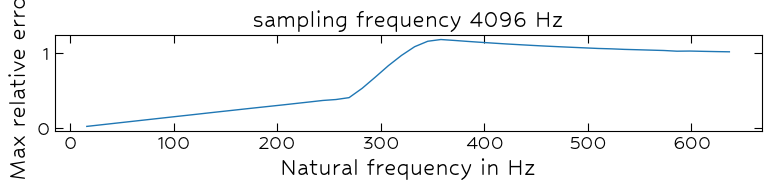

In [44]:
_ = plt.figure(figsize=(8, 2))
physical_frequencies = np.array(natural_frequencies_rk4)/(2*np.pi)
plt.plot(physical_frequencies, errors_rk4)
thesis_plot(yl="Max relative error", xl="Natural frequency in Hz", title="sampling frequency 4096 Hz")

Now, how much better does an adaptive step size solver fare?

In [39]:
natural_frequencies_diffrax = np.linspace(100, 4000, 5)
errors_diffrax = []
for omega0 in natural_frequencies_diffrax:

    oscillator_prior_dct = {
        "frequency": {"offset_mean": omega0, "offset_std": (1e-5, 1e-16), "fluctuations": (1e-16, 1e-16), "loglogavgslope": (-4, 1e-16)},  # log fluctuations...
        "damping": {"offset_mean": 0, "offset_std": (1e-5, 1e-16), "fluctuations": (1e-16, 1e-16), "loglogavgslope": (-4, 1e-16)},
        "force": {"offset_mean": 0, "offset_std": (1e-5, 1e-16), "fluctuations": (1e-16, 1e-16), "loglogavgslope": (0, 0.001), },
        "global_amplitude": (1, 1e-16),
        "init_condition": (1, 0),
    }

    signal_prior = StochasticOscillatorPrior(oscillator_prior_dct, signal_time_domain=signal_domain, localize_force=None, couple_force_to_frequency=False)
    oscillator = HarmonicOscillator(signal_domain_times=signal_domain, signal_prior=signal_prior, solver='diffrax', dfe='rhs_simple_ho', normalize=False)
    times = oscillator.evolution_times

    key, waveform_sample, omega_sample, gamma_sample, force_sample = get_oscillator_sample(oscillator, key)
    max_err = jnp.max(waveform_sample - jnp.cos(omega0 * (times-times[0])))
    errors_diffrax.append(max_err)



You are trying to set up the frequency prior for the oscillator with mean 100.0±(1e-05, 1e-16). To ensure positivity, 
we are exponentiating internally and therefore changing the mean and standard deviation values to 
 9.21±((Array(0., dtype=float64), Array(0., dtype=float64))).
If you are unsure this has the desired effect, check samples via `StochasticOscillatorPrior.plot_omega_samples`.






/Users/iason/PycharmProjects/STRAIN/phase_III/strain/signal/numerical_solver.py:187: UserWarning: manually fixing max steps to 50_000, revisit in future
  raise_warning("manually fixing max steps to 50_000, revisit in future")



You are trying to set up the frequency prior for the oscillator with mean 1075.0±(1e-05, 1e-16). To ensure positivity, 
we are exponentiating internally and therefore changing the mean and standard deviation values to 
 13.96±((Array(0., dtype=float64), Array(0., dtype=float64))).
If you are unsure this has the desired effect, check samples via `StochasticOscillatorPrior.plot_omega_samples`.





You are trying to set up the frequency prior for the oscillator with mean 2050.0±(1e-05, 1e-16). To ensure positivity, 
we are exponentiating internally and therefore changing the mean and standard deviation values to 
 15.25±((Array(0., dtype=float64), Array(0., dtype=float64))).
If you are unsure this has the desired effect, check samples via `StochasticOscillatorPrior.plot_omega_samples`.





You are trying to set up the frequency prior for the oscillator with mean 3025.0±(1e-05, 1e-16). To ensure positivity, 
we are exponentiating internally and therefore changing the mean and standard d

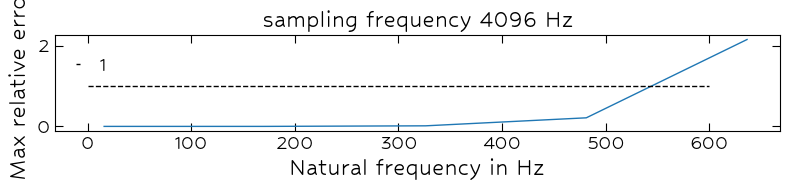

In [45]:
_ = plt.figure(figsize=(8, 2))
physical_frequencies = np.array(natural_frequencies)/(2*np.pi)
plt.plot(physical_frequencies, errors)
plt.hlines(1, 0, 600, ls="--", color="black", label="1")
thesis_plot(yl="Max relative error", xl="Natural frequency in Hz", title="sampling frequency 4096 Hz")

Diffrax fares better, but needs moch more computational resources and for higher natural frequencies gives the wrong result, i.e. does not universally solve the problem. Therefore even with diffrax we would need to increase the sampling frequency. In this case it makes more sense to me to use an rk4 with a super high signal resolution.

Let's say that GWs in the current LIGO setup are most likely to be found within the 10Hz - 300 Hz range with an upper cut-off at 1kHz. So the max angular natural frequency should be $\approx 7000 \mathrm{rad}/s$. What kind of r_fac should we pick?

In [46]:
omega0 = 7000

GW150914 = StrainSignalInference(
    key=key,
    event_name="GW150914",
    detector="H1",
    data_duration_of_hdf5_file="4096sec",
    stationarity_time_scale=32,
    e_fac=1,
    r_fac=100,
    alpha_taper_on_data=.1,
    out_name='osc_dlt_later'
)

signal_domain = GW150914.machinery.t_ss
dt = signal_domain[1]-signal_domain[0]
print("dt and inverse: ", dt, dt**-1, " and N: ", len(signal_domain))
target_domain = GW150914.machinery.t_ds

oscillator_prior_dct = {
    "frequency": {"offset_mean": omega0, "offset_std": (1e-5, 1e-16), "fluctuations": (1e-16, 1e-16), "loglogavgslope": (-4, 1e-16)},  # log fluctuations...
    "damping": {"offset_mean": 0, "offset_std": (1e-5, 1e-16), "fluctuations": (1e-16, 1e-16), "loglogavgslope": (-4, 1e-16)},
    "force": {"offset_mean": 0, "offset_std": (1e-5, 1e-16), "fluctuations": (1e-16, 1e-16), "loglogavgslope": (0, 0.001), },
    "global_amplitude": (1, 1e-16),
    "init_condition": (1, 0),
}

signal_prior = StochasticOscillatorPrior(oscillator_prior_dct, signal_time_domain=signal_domain, localize_force=None, couple_force_to_frequency=False)
oscillator = HarmonicOscillator(signal_domain_times=signal_domain, signal_prior=signal_prior, solver='rk4', dfe='rhs_simple_ho', normalize=False)

Assumed noise stationarity timescale for Welch-average:  32  seconds.
	Constructing 15 windows over which we average.
	Mean variance of tapered windows: 4.54237106804325
	Compare with area under welch ps:  4.5444512277217575
Hermitian symmetry OK. Max difference between pos and neg is  4.440892098500626e-16

Waveform query for GW150914. Found 1 local matche(s):
	0: 	IGWN-GWTC2p1-v2-GW150914_095045_PEDataRelease_mixed_cosmo.h5
Using  IGWN-GWTC2p1-v2-GW150914_095045_PEDataRelease_mixed_cosmo.h5


2026-04-07  14:12:58 PESummary WARNING : Could not find f_start in input file and one was not passed from the command line. Using 20.0Hz as default


Waveform model bank names:  C01:IMRPhenomXPHM C01:Mixed C01:SEOBNRv4PHM
Using  IMRPhenomXPHM  model.
Input gps center:  1126259462.4  maximum likelihood merger time from template:  1126259462.4241831
dt and inverse:  2.4414062500532907e-06 409599.9999910593  and N:  819200

You are trying to set up the frequency prior for the oscillator with mean 7000.0±(1e-05, 1e-16). To ensure positivity, 
we are exponentiating internally and therefore changing the mean and standard deviation values to 
 17.71±((Array(0., dtype=float64), Array(0., dtype=float64))).
If you are unsure this has the desired effect, check samples via `StochasticOscillatorPrior.plot_omega_samples`.


The following shows the solution to a simple harmonic oscillator (no force, no damping, constant natural frequency).
The sampling frequency is  409599.9999910593  while the natural frequency is  1114.0846016432674  Hz.
The max deviation from the analytic solution is  0.017108641874684874


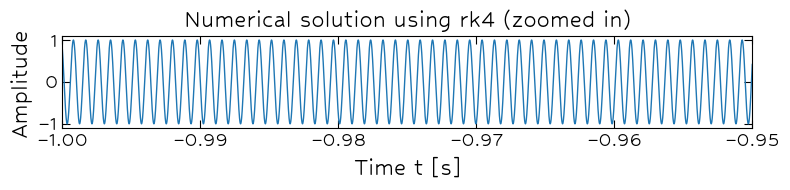

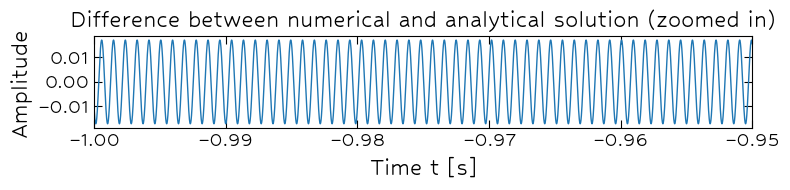

In [49]:
key, waveform_sample, omega_sample, gamma_sample, force_sample = get_oscillator_sample(oscillator, key)
times = oscillator.evolution_times
dt = times[1]-times[0]
res = waveform_sample - np.cos(omega0 * (times-times[0]))

print("The following shows the solution to a simple harmonic oscillator (no force, no damping, constant natural frequency).")
print("The sampling frequency is ", 1/dt, " while the natural frequency is ", omega0/(2*np.pi), " Hz.")
print("The max deviation from the analytic solution is ", np.abs(np.max(res)))

_ = plt.figure(figsize=(8, 2))
plt.plot(times, waveform_sample)
thesis_plot(yl="Amplitude", title="Numerical solution using rk4 (zoomed in)", xlim=(-1, -0.95))

_ = plt.figure(figsize=(8, 2))
plt.plot(times, res)
thesis_plot(yl="Amplitude", title="Difference between numerical and analytical solution (zoomed in)",  xlim=(-1, -0.95))

I would say $\texttt{r\_fac}=100$ does the trick. Does it reproduce other known simple (damped) harmonic oscillator solutions faithfully?

Note that in the equation

$$ \ddot{h}+\gamma_0\dot{h} + \omega_0^2h = 0 $$

critical damping is achieved when $\gamma_0 = 2\omega_0$.

In [113]:
def analytic_solution_to_damped_harmonic_oscillator(t, omega0, gamma0):
    """
    Due to ChatGpt / Claude
    Solve: h'' + gamma0 h' + omega0^2 h = 0
    with initial conditions h(0)=1, h'(0)=0
    """

    t = jnp.asarray(t)
    gamma0 = jnp.asarray(gamma0)
    omega0 = jnp.asarray(omega0)

    disc = gamma0**2 - 4 * omega0**2

    def underdamped(_):
        Omega = jnp.sqrt(omega0**2 - (gamma0**2) / 4)
        return jnp.exp(-gamma0 * t / 2) * (
            jnp.cos(Omega * t) + (gamma0 / (2 * Omega)) * jnp.sin(Omega * t)
        )

    def critical(_):
        return (1 + (gamma0 / 2) * t) * jnp.exp(-(gamma0 / 2) * t)

    def overdamped(_):
        sqrt_disc = jnp.sqrt(disc)
        lam_plus = (-gamma0 + sqrt_disc) / 2
        lam_minus = (-gamma0 - sqrt_disc) / 2
        return (
            lam_minus * jnp.exp(lam_plus * t)
            - lam_plus * jnp.exp(lam_minus * t)
        ) / (lam_minus - lam_plus)

    return jnp.where(
        disc < 0,
        underdamped(None),
        jnp.where(
            disc == 0,
            critical(None),
            overdamped(None)
        )
    )

def envelope_underdamped(t, gamma0, omega0):
    Omega = jnp.sqrt(omega0**2 - (gamma0**2) / 4)
    amplitude = jnp.sqrt(1 + (gamma0 / (2 * Omega))**2)
    return amplitude * jnp.exp(-gamma0 * t / 2)

In [118]:
omega0 = 2000
gamma0 = 10
oscillator_prior_dct = {
    "frequency": {"offset_mean": omega0, "offset_std": (1e-5, 1e-16), "fluctuations": (1e-16, 1e-16), "loglogavgslope": (-4, 1e-16)},  # log fluctuations...
    "damping": {"offset_mean": gamma0, "offset_std": (1e-5, 1e-16), "fluctuations": (1e-16, 1e-16), "loglogavgslope": (-4, 1e-16)},
    "force": {"offset_mean": 0, "offset_std": (1e-5, 1e-16), "fluctuations": (1e-16, 1e-16), "loglogavgslope": (0, 0.001), },
    "global_amplitude": (1, 1e-16),
    "init_condition": (1, 0),
}

signal_prior = StochasticOscillatorPrior(oscillator_prior_dct, signal_time_domain=signal_domain, localize_force=None, couple_force_to_frequency=False)
oscillator = HarmonicOscillator(signal_domain_times=signal_domain, signal_prior=signal_prior, solver='rk4', dfe='rhs_damped_simple_ho', normalize=False)


You are trying to set up the frequency prior for the oscillator with mean 2000.0±(1e-05, 1e-16). To ensure positivity, 
we are exponentiating internally and therefore changing the mean and standard deviation values to 
 15.200000000000001±((Array(0., dtype=float64), Array(0., dtype=float64))).
If you are unsure this has the desired effect, check samples via `StochasticOscillatorPrior.plot_omega_samples`.


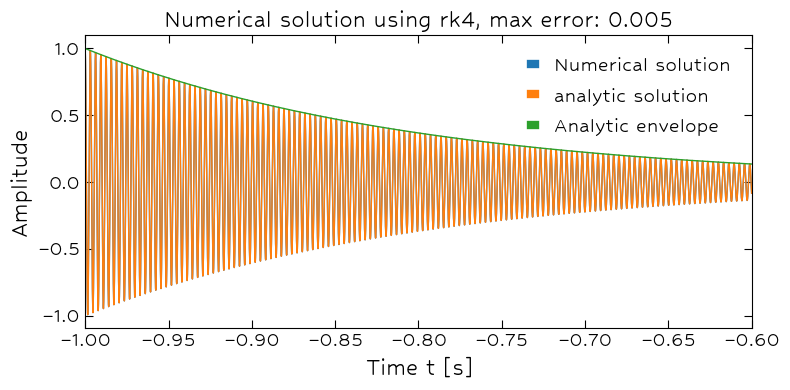

In [119]:
key, waveform_sample, omega_sample, gamma_sample, force_sample = get_oscillator_sample(oscillator, key)
ana_solution = analytic_solution_to_damped_harmonic_oscillator(t=times-times[0], omega0=omega0, gamma0=gamma0)
res = waveform_sample - ana_solution
env = envelope_underdamped(times-times[0], gamma0, omega0)
m = jnp.round(jnp.max(jnp.abs(res)),3)

_ = plt.figure(figsize=(8, 4))
plt.plot(times, waveform_sample, label="Numerical solution")
plt.plot(times, ana_solution, label="analytic solution")
plt.plot(times, env, label="Analytic envelope")
thesis_plot(mode="longer",yl="Amplitude", title=f"Numerical solution using rk4, max error: {m}", xlim=(-1, -0.6))

It seems to me right now likely that the phenomenen I saw where I had a reduced waveform amplitude each time the frequency got higher when the natural angular frequency $\omega(t)$ was allowed to vary, occured due to the discretization effect.